In [1]:
import requests
import json
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import pprint
import pickle

In [2]:
### warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
## Karolinska Institutet
ki_ror="https://ror.org/056d84691"

In [194]:


# specify endpoint
endpoint = 'works'

# build the 'filter' parameter
# We'll limit it to the last 20 years
filters = ",".join((
    f'institutions.ror:{ki_ror}',
    'from_publication_date:2003-01-01',
))

# put the URL together
filtered_works_url = f'https://api.openalex.org/{endpoint}?filter={filters}'
# if email:
#     filtered_works_url += f"&mailto={email}"
print(f'complete URL with filters:\n{filtered_works_url}')

complete URL with filters:
https://api.openalex.org/works?filter=institutions.ror:https://ror.org/056d84691,from_publication_date:2003-01-01


In [ ]:
# url = f'{filtered_works_url}&select={select}&cursor={cursor}'
# #     page_with_results = requests.get(url).json()

In [195]:
r = requests.get(filtered_works_url)
results_page = r.json()
print(f"retrieved {len(results_page['results'])} works")

retrieved 25 works


In [196]:
print(results_page['meta']['count'])

112741


In [197]:
pwd

'/home/sipan/api_works/openAlex'

In [198]:
# there are 25 results per page
results_page['meta']['count'] / 25

4509.64

In [162]:
# works = []
# loop_index = 0
# cursor = '*'
# url = f'{filtered_works_url}&cursor={cursor}'
# page_with_results = requests.get(url).json()
# results = page_with_results['results']
# works.extend(results)

In [164]:
# works

In [200]:
## uncomment for first time
## loop through pages
# works = []
# loop_index = 0
# cursor = '*'
# url = f'{filtered_works_url}&cursor={cursor}'
# page_with_results = requests.get(url).json()
# results = page_with_results['results']
# works.extend(results)



# while cursor:
    
#     # set cursor value and request page from OpenAlex
#     url = f'{filtered_works_url}&cursor={cursor}'
#     page_with_results = requests.get(url).json()
    
#     results = page_with_results['results']
#     works.extend(results)

#     # update cursor to meta.next_cursor
#     cursor = page_with_results['meta']['next_cursor']
#     loop_index += 1
#     if loop_index in [5, 10, 20, 50, 100] or loop_index % 500 == 0:
#         print(f'{loop_index} api requests made so far')
# print(f'done. made {loop_index} api requests. collected {len(works)} works')

5 api requests made so far
10 api requests made so far
20 api requests made so far
50 api requests made so far
100 api requests made so far
500 api requests made so far
1000 api requests made so far
1500 api requests made so far
2000 api requests made so far
2500 api requests made so far
3000 api requests made so far
3500 api requests made so far
4000 api requests made so far
4500 api requests made so far
done. made 4511 api requests. collected 112758 works


In [201]:
len(works)

112758

In [202]:
# # saving data in pickle
# import pickle
# import os

# with open('data/ki_works_openalex_2003_2023.pickle', 'wb') as outf:
#     pickle.dump(works, outf, protocol=pickle.HIGHEST_PROTOCOL)


In [4]:
# OR uncomment these lines and run to load the saved results
with open('data/ki_works_openalex_2003_2023.pickle', 'rb') as f:
    works = pickle.load(f)

In [5]:
len(works)

112758

In [6]:
# works[1090]
works[1000]["type"]
works[1000]["open_access"]["oa_status"]

'green'

In [37]:

# data = []
# for work in works:
#     work_type=work["type"] if work["type"] else None
#     work_status=work["open_access"]["oa_status"] if work["open_access"]["oa_status"] else None
#     for authorship in work['authorships']:
#         if authorship:
#             author = authorship['author']
#             author_id = author['id'] if author else None
#             author_name = author['display_name'] if author else None
#             author_position = authorship['author_position']
#             for institution in authorship['institutions']:
#                 if institution:
#                     institution_id = institution['id']
#                     institution_name = institution['display_name']
#                     institution_country_code = institution['country_code']
#                     data.append({
#                         "work_id": work['id'],
#                         "work_type":work_type,
#                         "work_status": work_status,
#                         'work_title': work['title'],
#                         'work_display_name': work['display_name'],
#                         'work_publication_year': work['publication_year'],
#                         'work_publication_date': work['publication_date'],
#                         'author_id': author_id,
#                         'author_name': author_name,
#                         'author_position': author_position,
#                         'institution_id': institution_id,
#                         'institution_name': institution_name,
#                         'institution_country_code': institution_country_code,
#                     })
# df = pd.DataFrame(data)

In [94]:
# # works[1090]
# print(works[1090].keys())
# works[1090]["id"]
# works[1090]["title"]
# works[1090]["type"]
# works[1090]["open_access"]["oa_status"]
# works[1090]["display_name"]
# works[1090]["publication_year"]
# works[1090]["cited_by_count"]
# works[1090]["ids"]
# works[1090]["primary_location"]["source"]["display_name"]
# works[1090]["primary_location"]["source"]["host_organization_name"]
# works[1090]["primary_location"]["source"]["issn"]
# works[1090]["corresponding_author_ids"]
# works[1090]["corresponding_author_ids"]
# works[1090]["corresponding_institution_ids"]
# works[1090]["apc_payment"]
# works[1090]["biblio"]
# works[1090]["counts_by_year"]


In [7]:
data=[]
print("Total records:",len(works))
print(works[9].keys())
for work in works:
    data.append(
        {
        "work_id":work["id"],
        "work_type":work["title"], 
        "work_type":work["type"],
        "work oa":work["open_access"]["oa_status"],
        "works dispaly name":work["display_name"],
        "publication_year":work["publication_year"],
        "cited_by_count":work["cited_by_count"],
        "counts_by_year":work["counts_by_year"],
        "ids":work["ids"],
        "source":work["primary_location"]["source"]["display_name"] if work["primary_location"]["source"] else None,
        "journal":work["primary_location"]["source"]["host_organization_name"]if work["primary_location"]["source"] else None,
        "issn":work["primary_location"]["source"]["issn"] if work["primary_location"]["source"] else None,
        "corresponding_author_ids":work["corresponding_author_ids"],
        "corresponding_institution_ids":work["corresponding_institution_ids"],
        "apc_payment":work["apc_payment"],
        "biblio":work["biblio"]
        }
    )
df = pd.DataFrame(data)

Total records: 112758
dict_keys(['id', 'doi', 'title', 'display_name', 'publication_year', 'publication_date', 'ids', 'language', 'primary_location', 'type', 'open_access', 'authorships', 'corresponding_author_ids', 'corresponding_institution_ids', 'apc_payment', 'cited_by_count', 'biblio', 'is_retracted', 'is_paratext', 'concepts', 'mesh', 'locations_count', 'locations', 'best_oa_location', 'grants', 'referenced_works', 'related_works', 'ngrams_url', 'abstract_inverted_index', 'cited_by_api_url', 'counts_by_year', 'updated_date', 'created_date'])


In [8]:
df.head(5)

,work_id,work_type,work oa,works dispaly name,publication_year,cited_by_count,counts_by_year,ids,source,journal,issn,corresponding_author_ids,corresponding_institution_ids,apc_payment,biblio
0,https://openalex.org/W2124026197,journal-article,hybrid,Features and development of <i>Coot</i>,2010,20283,"[{'year': 2023, 'cited_by_count': 855}, {'year...",{'openalex': 'https://openalex.org/W2124026197...,None,None,None,[],[],None,"{'volume': '66', 'issue': '4', 'first_page': '..."
1,https://openalex.org/W2171129594,journal-article,bronze,International Physical Activity Questionnaire:...,2003,13570,"[{'year': 2023, 'cited_by_count': 527}, {'year...",{'openalex': 'https://openalex.org/W2171129594...,Medicine and Science in Sports and Exercise,Lippincott Williams & Wilkins,"[1530-0315, 0195-9131]",[],[],None,"{'volume': '35', 'issue': '8', 'first_page': '..."
2,https://openalex.org/W2025371271,journal-article,closed,Minimal criteria for defining multipotent mese...,2006,13214,"[{'year': 2023, 'cited_by_count': 348}, {'year...",{'openalex': 'https://openalex.org/W2025371271...,Cytotherapy,Elsevier BV,"[1465-3249, 1477-2566]",[https://openalex.org/A4359345567],[https://openalex.org/I122346577],None,"{'volume': '8', 'issue': '4', 'first_page': '3..."
3,https://openalex.org/W2012034410,journal-article,closed,Tissue-based map of the human proteome,2015,9023,"[{'year': 2023, 'cited_by_count': 582}, {'year...",{'openalex': 'https://openalex.org/W2012034410...,Science,American Association for the Advancement of Sc...,"[0036-8075, 1095-9203]",[https://openalex.org/A4358309292],"[https://openalex.org/I86987016, https://opena...",None,"{'volume': '347', 'issue': '6220', 'first_page..."
4,https://openalex.org/W2163710303,journal-article,green,"Global, regional, and national prevalence of o...",2014,8673,"[{'year': 2023, 'cited_by_count': 197}, {'year...",{'openalex': 'https://openalex.org/W2163710303...,The Lancet,Elsevier BV,"[1474-547X, 0099-5355, 0140-6736]",[https://openalex.org/A2309765197],[https://openalex.org/I3143470655],None,"{'volume': '384', 'issue': '9945', 'first_page..."


work oa
bronze     530
closed    1999
gold      2766
green     1644
hybrid    2078
Name: work_type, dtype: int64

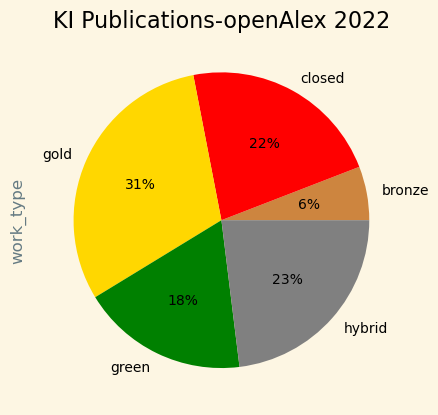

In [17]:

# Count open access by year
# for year in range(2003,2023):
plt.style.use('Solarize_Light2')
year=2022
data=df[df["publication_year"]==year].groupby("work oa")["work_type"].count()

colors={
    "bronze":"peru",
    "closed":"red",
    "gold":"gold",
    "green":"green",     
     "hybrid":"grey"
}

df[df["publication_year"]==year].groupby("work oa")["work_type"].count().plot.pie(
    labels = data.index,
    autopct='%.0f%%',
    colors=[colors[index] for index in data.index],
    title="KI Publications-openAlex "+f"{year}",
    legend=False
)


display(data)

<AxesSubplot: title={'center': 'KTH Publications-openAlex'}, xlabel='work oa'>

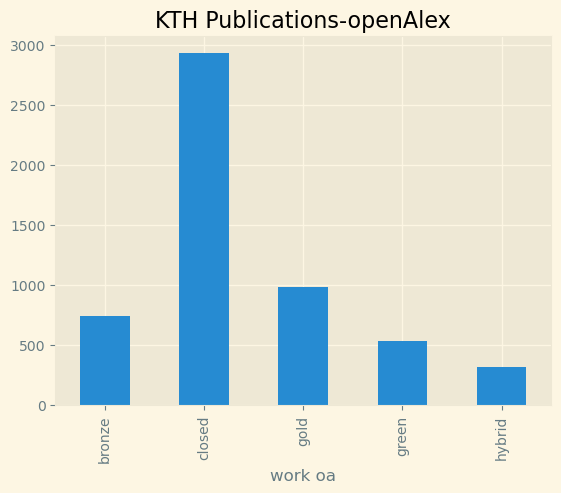

In [18]:
# df[df["publication_year"]==2013]
# for year in range(2003,2024):
#     print(year)

    
df[df["publication_year"]==2013].groupby("work oa")["work_type"].count().plot.bar(
    # labels = data.index,
    # autopct='%.0f%%',
    # colors=[colors[index] for index in data.index],
    title="KTH Publications-openAlex",
    legend=False
)


In [104]:
df[["work_type","work oa","journal","publication_year"]].groupby("publication_year").count()

,work_type,work oa,journal
publication_year,,,
2003,1289,1289,917
2004,1430,1430,1006
2005,1494,1494,1044
2006,1800,1800,1279
2007,1946,1946,1304
2008,1732,1732,1193
2009,2146,2146,1359
2010,2389,2389,1467
2011,2736,2736,1636


<AxesSubplot: xlabel='publication_year'>

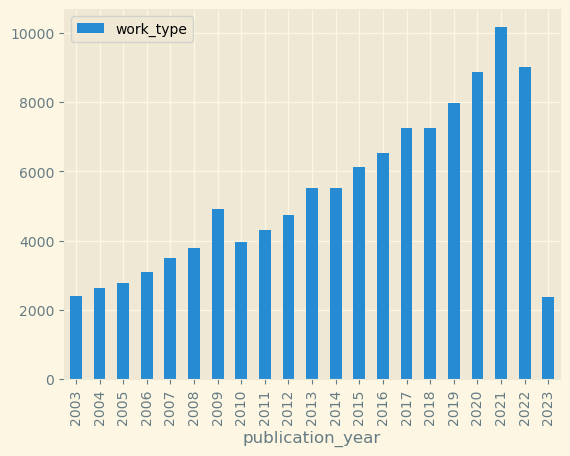

In [16]:
plt.style.use('Solarize_Light2')
df[["work_type","publication_year"]].groupby("publication_year").count().plot.bar()

In [78]:
# works[180]

In [44]:
data = []
for work in works:
    work_type=work["type"] if work["type"] else None
    work_status=work["open_access"]["oa_status"] if work["open_access"]["oa_status"] else None
    for authorship in work['authorships']:
        if authorship:
            author = authorship['author']
            author_id = author['id'] if author else None
            author_name = author['display_name'] if author else None
            author_position = authorship['author_position']
            data.append({
                        "work_id": work['id'],
                        "work_type":work_type,
                        "work_status": work_status,
                        'work_title': work['title'],
                        'work_display_name': work['display_name'],
                        'work_publication_year': work['publication_year'],
                        'work_publication_date': work['publication_date'],
                        'author_id': author_id,
                        'author_name': author_name,
                        'author_position': author_position,
                        # 'institution_country_code': authorship['institutions']['country_code'],
                    })
df = pd.DataFrame(data)

In [ ]:
df

,work_id,work_type,work_status,work_title,work_display_name,work_publication_year,work_publication_date,author_id,author_name,author_position
0,https://openalex.org/W1031578623,journal-article,gold,GROMACS: High performance molecular simulation...,GROMACS: High performance molecular simulation...,2015,2015-09-01,https://openalex.org/A4352596074,Mark Abraham,first
1,https://openalex.org/W1031578623,journal-article,gold,GROMACS: High performance molecular simulation...,GROMACS: High performance molecular simulation...,2015,2015-09-01,https://openalex.org/A4353947941,Teemu J. Murtola,middle
2,https://openalex.org/W1031578623,journal-article,gold,GROMACS: High performance molecular simulation...,GROMACS: High performance molecular simulation...,2015,2015-09-01,https://openalex.org/A4334242285,Roland Schulz,middle
3,https://openalex.org/W1031578623,journal-article,gold,GROMACS: High performance molecular simulation...,GROMACS: High performance molecular simulation...,2015,2015-09-01,https://openalex.org/A4332627796,Szilárd Páll,middle
4,https://openalex.org/W1031578623,journal-article,gold,GROMACS: High performance molecular simulation...,GROMACS: High performance molecular simulation...,2015,2015-09-01,https://openalex.org/A4355470864,Jeremy C. Smith,middle
...,...,...,...,...,...,...,...,...,...,...
304666,https://openalex.org/W98962661,book-chapter,closed,Laterales Eigenverhalten und Stabilität von Dr...,Laterales Eigenverhalten und Stabilität von Dr...,2003,2003-01-01,https://openalex.org/A1788473959,Sebastian Stichel,last
304667,https://openalex.org/W990727780,book-chapter,closed,The Metric Tensor,The Metric Tensor,2015,2015-01-01,https://openalex.org/A2623806108,M. Dalarsson,first
304668,https://openalex.org/W990727780,book-chapter,closed,The Metric Tensor,The Metric Tensor,2015,2015-01-01,https://openalex.org/A2443624060,Nils Dalarsson,last
304669,https://openalex.org/W999906588,journal-article,closed,Climate change scenarios and behavioural chang...,Climate change scenarios and behavioural chang...,2008,2008-01-01,https://openalex.org/A113670478,Ulrika Gunnarsson-Östling,first
